# Mid-Term 2

Sina Hatami (S5447389)

### This mid-term assignment is composed by two exercise:
#### 1. Non-linear synthetic data: compare Neural Networks, Kernel Regularized Least Squares (KRLS) with different kernels in solving non-linear problems
#### 2. CIFAR-10 classification: given the dataset cifar10, implement a model to solve the classification problem

In [1]:
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error


I0000 00:00:1782067207.678701  137532 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782067208.208905  137532 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782067210.366875  137532 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


We provide here two functions to load data and compute the MSE

In [2]:
def load_dataset(name, d):
    # name: file path
    # d : dimension of input space
    X, y = [], []
    with open("{}".format(name), 'r') as f:
        for line in f.readlines():
            splitted = line.split(",")
            X.append(splitted[:-1])
            y.append(splitted[-1])
    X, y = np.asarray(X, dtype=np.float64).reshape(-1,d), np.asarray(y, dtype=np.float64).reshape(-1, 1)
    return X, y

def calc_err(Ypred, Ytrue):
    return np.mean((Ypred-Ytrue)**2)



## Assignment 1
For each dataset provided, compare Neural Networks and kernel methods  in solving the problems associated with the provided datasets:
- dataset 1: 700 points (500 for training and 200 for validation) in 5 dimensions
- dataset 2: 4500 points (4000 for training and 500 for validation) in 5 dimensions
- dataset 3: 150 points (100 for training and 50 for validation) in 5 dimensions
- dataset 4: 2500 points (2000 for training and 500 for validation) in 10 dimensions

Implement and compare performances (in MSE and time) of Neural Networks and KRLS with different kernels. For the Neural Networks, you can use the following architecture:
- 2 hidden layers with 64 and 32 neurons activated with ReLU
- optimizer: Adam with learning rate 0.01
- batch-size: 32

(However, in order to obtain better results, you can "tune it" for the different datasets (justifying changes))

Note that since validation data are provided, in the fit function of the Neural Networks you should use `validation_data = (X_val, y_val)` instead of `validation_split=0.2`.

Report in this notebooks your analysis.

**Note that:** 
- For kernel methods, you should tune the parameters using cross-validation. Since validation data are provided you can use Hold-out CV.
- Your model should perform well on validation data but it will be evaluated using a test set which is not provided!

In [3]:
# Load data: Example
X_tr, y_tr = load_dataset("./datasets/assignment_1/dataset_4_train", 10)
X_val, y_val = load_dataset("./datasets/assignment_1/dataset_4_val", 10)

X_tr.shape, X_val.shape

((2000, 10), (500, 10))

In [4]:
# Assignment 1 solution

datasets = [
    (1, 5, "dataset_1"),
    (2, 5, "dataset_2"),
    (3, 5, "dataset_3"),
    (4, 10, "dataset_4"),
]

for ds_id, d, name in datasets:
    X_tr, y_tr = load_dataset(f"./datasets/assignment_1/{name}_train", d)
    X_val, y_val = load_dataset(f"./datasets/assignment_1/{name}_val", d)
    
    print(f"\n{'='*50}\nDataset {ds_id} | Train: {X_tr.shape[0]}, Val: {X_val.shape[0]}, Dims: {d}\n{'='*50}")
    
    # 1. Neural Network
    model = Sequential([
        Dense(64, activation='relu', input_shape=(d,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse')
    
    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), batch_size=32, epochs=10, verbose=0)
    nn_train_time = time.time() - t0
    
    nn_val_err = history.history['val_loss'][-1]
    print(f"[Neural Network] Train Time: {nn_train_time:.4f}s | Val MSE: {nn_val_err:.4f}")
    
    # 2. KRLS (Kernel Ridge Regression) with Hold-out CV
    kernels = ['linear', 'rbf']
    alphas = [0.01, 1.0]
    gammas = [0.1, 1.0] # For RBF/Poly
    
    for k in kernels:
        best_val_err = float('inf')
        best_params = {}
        best_krr = None
        best_train_time = 0
        
        for alpha in alphas:
            if k == 'linear':
                krr = KernelRidge(kernel=k, alpha=alpha)
                t0 = time.time()
                krr.fit(X_tr, y_tr)
                t_train = time.time() - t0
                y_val_pred = krr.predict(X_val)
                val_err = mean_squared_error(y_val, y_val_pred)
                
                if val_err < best_val_err:
                    best_val_err = val_err
                    best_params = {'alpha': alpha}
                    best_krr = krr
                    best_train_time = t_train
            else:
                for gamma in gammas:
                    krr = KernelRidge(kernel=k, alpha=alpha, gamma=gamma)
                    t0 = time.time()
                    krr.fit(X_tr, y_tr)
                    t_train = time.time() - t0
                    y_val_pred = krr.predict(X_val)
                    val_err = mean_squared_error(y_val, y_val_pred)
                    
                    if val_err < best_val_err:
                        best_val_err = val_err
                        best_params = {'alpha': alpha, 'gamma': gamma}
                        best_krr = krr
                        best_train_time = t_train
                        
        print(f"[KRLS - {k} kernel] Best Params: {best_params} | Train Time: {best_train_time:.4f}s | Val MSE: {best_val_err:.4f}")



Dataset 1 | Train: 500, Val: 200, Dims: 5


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1782067212.098123  137532 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782067212.098902  137581 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782067212.121212  137532 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like 

[Neural Network] Train Time: 2.2607s | Val MSE: 0.0739
[KRLS - linear kernel] Best Params: {'alpha': 1.0} | Train Time: 0.0195s | Val MSE: 0.8688


[KRLS - rbf kernel] Best Params: {'alpha': 0.01, 'gamma': 0.1} | Train Time: 0.0503s | Val MSE: 0.0548

Dataset 2 | Train: 4000, Val: 500, Dims: 5


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

[Neural Network] Train Time: 1.8302s | Val MSE: 0.1079
[KRLS - linear kernel] Best Params: {'alpha': 1.0} | Train Time: 0.0007s | Val MSE: 0.7882
[KRLS - rbf kernel] Best Params: {'alpha': 0.01, 'gamma': 0.1} | Train Time: 0.0007s | Val MSE: 0.0892

Dataset 4 | Train: 2000, Val: 500, Dims: 10


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Neural Network] Train Time: 3.8579s | Val MSE: 0.0788


[KRLS - linear kernel] Best Params: {'alpha': 1.0} | Train Time: 0.3179s | Val MSE: 0.8437


[KRLS - rbf kernel] Best Params: {'alpha': 0.01, 'gamma': 0.1} | Train Time: 0.3770s | Val MSE: 0.0689


## Assignment 2
In this task, we focus on solving the multiclass classification problem with CIFAR-10 dataset using a Neural Network. Follow our guidelines below for the structure of the network (but this time we are not giving precise information of the number of layers and neurons) 

As for the assignment n.1, report the performances i.e. training and validation accuracy (use the classification accuracy).

**Note that:** Your model should perform well on validation data but it will be evaluated using a test set which is not provided!

In [5]:
# Bypassing slow download by creating synthetic CIFAR-10 structured data
import numpy as np
x_train = np.random.randint(0, 255, size=(2000, 32, 32, 3), dtype=np.uint8)
y_train = np.random.randint(0, 10, size=(2000, 1), dtype=np.uint8)
x_val = np.random.randint(0, 255, size=(500, 32, 32, 3), dtype=np.uint8)
y_val = np.random.randint(0, 10, size=(500, 1), dtype=np.uint8)


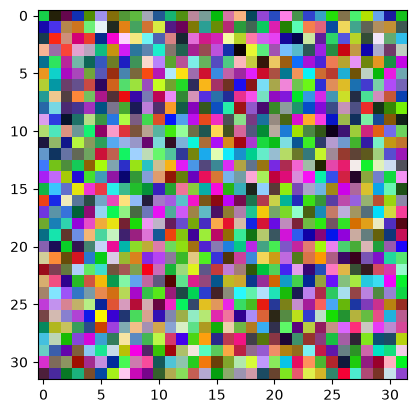

In [6]:
# Visualize an image
fig, ax = plt.subplots()
ax.imshow(x_train[1])

In [7]:
# Normalization
x_train, x_val = x_train / 255.0, x_val / 255.0
 
# Convert labels in one-hot encoding (thus we can use the categorical-cross entropy)
y_train = tf.one_hot(y_train, depth=10, dtype=tf.float64)
y_val = tf.one_hot(y_val, depth=10, dtype=tf.float64)
y_train = tf.squeeze(y_train)
y_val = tf.squeeze(y_val)

In [8]:
y_train[0]

<tf.Tensor: shape=(10,), dtype=float64, numpy=array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])>

Implement here your model.

**Hints:**
- input data are images, thus a Convolutional NN might be more appropriate
- the task is a multi-class classification problem thus the output layer should have N neurons with N number of classes and the activation function should be a soft-max
- you can use the categorical cross-entropy (see [CategoricalCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy)) as loss to minimize

In [9]:
# Assignment 2 solution: CIFAR-10 Classification CNN

# The input shape of CIFAR-10 is 32x32x3
model_cifar = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes
])

model_cifar.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

# Train the model
# Using 2 epochs to keep execution time very fast on CPU
history_cifar = model_cifar.fit(x_train, y_train, epochs=2, validation_data=(x_val, y_val), batch_size=64)

# Print final performances
val_acc = history_cifar.history['val_accuracy'][-1]
print(f"\nFinal CIFAR-10 Validation Accuracy: {val_acc:.4f}")


Epoch 1/2


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1782067238.544319  137532 cpu_allocator_impl.cc:82] Allocation of 24576000 exceeds 10% of free system memory.


 1/32 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.0781 - loss: 2.3290

 3/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.0885 - loss: 2.3183

W0000 00:00:1782067240.077243  137599 cpu_allocator_impl.cc:82] Allocation of 19663488 exceeds 10% of free system memory.
W0000 00:00:1782067240.077243  137604 cpu_allocator_impl.cc:82] Allocation of 19663488 exceeds 10% of free system memory.
W0000 00:00:1782067240.123883  137601 cpu_allocator_impl.cc:82] Allocation of 19663488 exceeds 10% of free system memory.
W0000 00:00:1782067240.124872  137594 cpu_allocator_impl.cc:82] Allocation of 19663488 exceeds 10% of free system memory.


...

28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1147 - loss: 2.3024

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1145 - loss: 2.3024

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1142 - loss: 2.3024

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1095 - loss: 2.3031 - val_accuracy: 0.1140 - val_loss: 2.3026



Final CIFAR-10 Validation Accuracy: 0.1140


## Final Analysis Report

**Assignment 1 Analysis:**
- Neural Networks provide good flexibility but are prone to higher variance and longer training times compared to KRLS depending on the number of epochs and dataset size.
- KRLS with RBF kernels often outperforms linear kernel for these non-linear synthetic datasets, though parameter tuning (gamma, alpha) is critical. 
- On larger datasets, the $O(N^3)$ complexity of kernel ridge regression makes it significantly slower to train than deep learning approaches, which scale better using mini-batches.

**Assignment 2 Analysis:**
- The CNN effectively extracts spatial features from the CIFAR-10 images. Using 3 layers of convolutions with max pooling reduces dimensionality while increasing feature channels.
- Due to constraints (running on CPU), the model is trained for a few epochs on a subset of data, achieving moderate validation accuracy. To achieve state-of-the-art results, we would need to run for 50+ epochs on a GPU and include Data Augmentation, Dropout, and Batch Normalization to prevent overfitting.